# IEEE-CIS Fraud Detection — EDA

Baseline exploration before any feature engineering. Goal: understand the
target distribution, data shapes, missingness, and a few obvious signals —
not to build features yet.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 60)
DATA_DIR = '../data/raw'

Matplotlib is building the font cache; this may take a moment.


## Load data

In [2]:
train_transaction = pd.read_csv(f'{DATA_DIR}/train_transaction.csv')
train_identity = pd.read_csv(f'{DATA_DIR}/train_identity.csv')

print('train_transaction:', train_transaction.shape)
print('train_identity:', train_identity.shape)

train_transaction: (590540, 394)
train_identity: (144233, 41)


`train_identity` only covers a subset of transactions — join is left on
`train_transaction` so unmatched rows get NaN identity features.

In [3]:
train = train_transaction.merge(train_identity, on='TransactionID', how='left')
print('merged:', train.shape)
train.head()

merged: (590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,...,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


## Target distribution

This is the whole reason accuracy is the wrong metric here.

Fraud rate: 3.4990%
isFraud
0    569877
1     20663
Name: count, dtype: int64


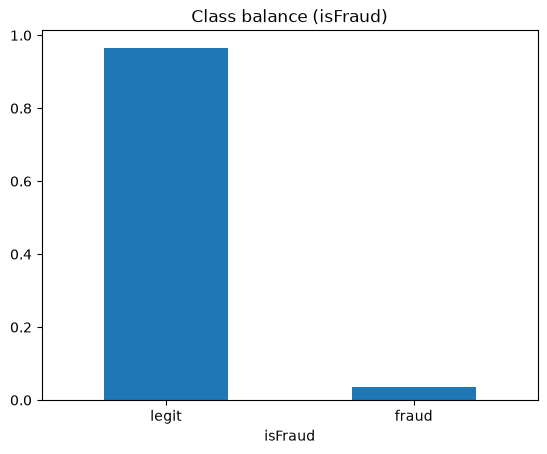

In [4]:
fraud_rate = train['isFraud'].mean()
print(f'Fraud rate: {fraud_rate:.4%}')
print(train['isFraud'].value_counts())

train['isFraud'].value_counts(normalize=True).plot(kind='bar', title='Class balance (isFraud)')
plt.xticks([0, 1], ['legit', 'fraud'], rotation=0)
plt.show()

## Missingness

Which columns are mostly empty? Relevant for what we can even use as features later.

In [5]:
missing = train.isnull().mean().sort_values(ascending=False)
missing.head(20)

id_24    0.991962
id_25    0.991310
id_07    0.991271
id_08    0.991271
id_21    0.991264
id_26    0.991257
id_27    0.991247
id_23    0.991247
id_22    0.991247
dist2    0.936284
D7       0.934099
id_18    0.923607
D13      0.895093
D14      0.894695
D12      0.890410
id_03    0.887689
id_04    0.887689
D6       0.876068
id_33    0.875895
id_10    0.873123
dtype: float64

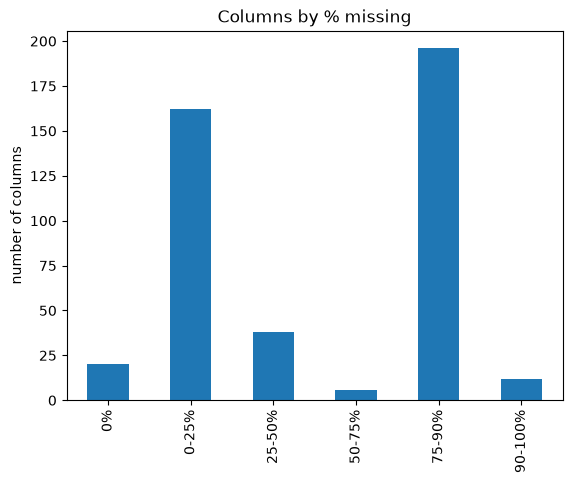

In [6]:
missing_bucket = pd.cut(missing, bins=[-0.01, 0, 0.25, 0.5, 0.75, 0.9, 1.0],
                         labels=['0%', '0-25%', '25-50%', '50-75%', '75-90%', '90-100%'])
missing_bucket.value_counts().sort_index().plot(kind='bar', title='Columns by % missing')
plt.ylabel('number of columns')
plt.show()

## Transaction amount

Distribution is heavily right-skewed, as expected for payment amounts.

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64


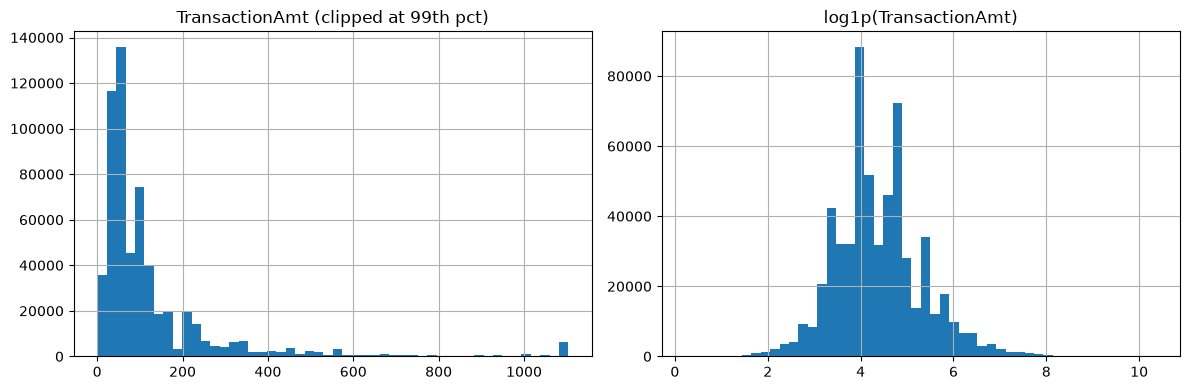

In [7]:
print(train['TransactionAmt'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train['TransactionAmt'].clip(upper=train['TransactionAmt'].quantile(0.99)).hist(bins=50, ax=axes[0])
axes[0].set_title('TransactionAmt (clipped at 99th pct)')

np.log1p(train['TransactionAmt']).hist(bins=50, ax=axes[1])
axes[1].set_title('log1p(TransactionAmt)')
plt.tight_layout()
plt.show()

In [8]:
train.groupby('isFraud')['TransactionAmt'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


## Categorical columns — cardinality check

High-cardinality categoricals (e.g. `card1`) need different handling than low-cardinality ones (e.g. `ProductCD`).

In [9]:
categorical_cols = ['ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
                     'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain']
for col in categorical_cols:
    if col in train.columns:
        print(f'{col}: {train[col].nunique()} unique values, {train[col].isnull().mean():.1%} missing')

ProductCD: 5 unique values, 0.0% missing
card1: 13553 unique values, 0.0% missing
card2: 500 unique values, 1.5% missing
card3: 114 unique values, 0.3% missing
card4: 4 unique values, 0.3% missing
card5: 119 unique values, 0.7% missing
card6: 4 unique values, 0.3% missing
addr1: 332 unique values, 11.1% missing
addr2: 74 unique values, 11.1% missing
P_emaildomain: 59 unique values, 16.0% missing
R_emaildomain: 60 unique values, 76.8% missing


## Notes / what stood out

_(Fill in as you go — this is the "what didn't work / what surprised me" log
that eventually feeds the README's approach section.)_

-
